In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

--- Kernel Performance Comparison ---
Linear Kernel Test Accuracy: 46.67%
RBF Kernel Test Accuracy:    98.33%



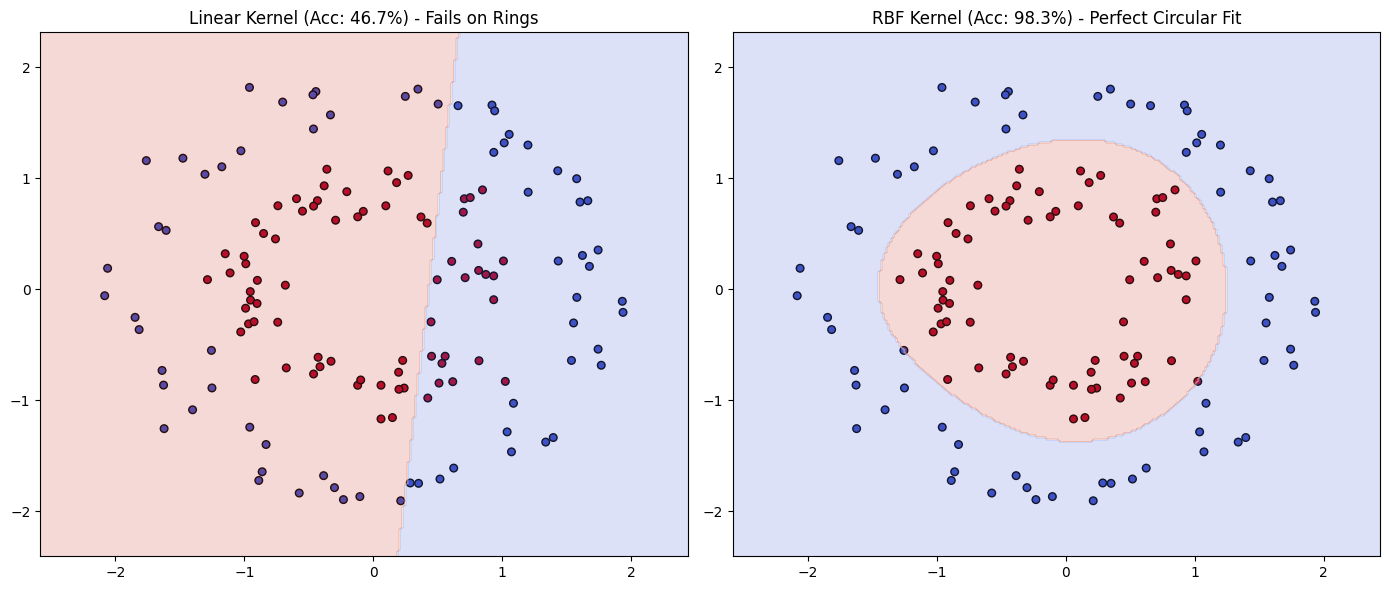

In [1]:
# Topic 117 | SVM - The Kernel Trick Explained
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Ek circular, non-linear dataset generate karein
# Isme ek class ke circles dusri class ke andar trapped hote hain
X, y = make_circles(n_samples=200, factor=0.5, noise=0.1, random_state=42)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scaling (SVM ke liye zaroori hai)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------------
# MODEL 1: Linear Kernel (Linear Boundary)
# ------------------------------------------------------------------
linear_svc = SVC(kernel="linear", random_state=42)
linear_svc.fit(X_train_scaled, y_train)
linear_acc = linear_svc.score(X_test_scaled, y_test)

# ------------------------------------------------------------------
# MODEL 2: RBF Kernel (The Kernel Trick Approach)
# ------------------------------------------------------------------
rbf_svc = SVC(kernel="rbf", gamma="scale", random_state=42)
rbf_svc.fit(X_train_scaled, y_train)
rbf_acc = rbf_svc.score(X_test_scaled, y_test)

print("--- Kernel Performance Comparison ---")
print(f"Linear Kernel Test Accuracy: {linear_acc * 100:.2f}%")
print(f"RBF Kernel Test Accuracy:    {rbf_acc * 100:.2f}%\n")


# 2. Decision Boundaries Plot Karne Ka Function
def plot_boundaries(model, X, y, ax, title):
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap="coolwarm", edgecolors="k")

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.2, cmap="coolwarm")
    ax.set_title(title)


# Plot comparison side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_boundaries(
    linear_svc,
    X_train_scaled,
    y_train,
    axes[0],
    f"Linear Kernel (Acc: {linear_acc*100:.1f}%) - Fails on Rings",
)
plot_boundaries(
    rbf_svc,
    X_train_scaled,
    y_train,
    axes[1],
    f"RBF Kernel (Acc: {rbf_acc*100:.1f}%) - Perfect Circular Fit",
)

plt.tight_layout()
plt.show()